In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, log_loss , confusion_matrix
import joblib

In [3]:
df = pd.read_csv('../../data/interim/olist_ml_processed_review_dataset.csv')

X_raw = df.drop(columns=['review_score']).values
y_raw = df['review_score'].values - 1

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Features go to float32; labels go to long (integers) for CrossEntropyLoss
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# --- Step 4: Create DataLoaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 256  # Adjust this depending on your preferences

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True          # Shuffle training data to help generalization
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False          # No need to shuffle test/evaluation data
)

print(f"DataLoaders successfully created!")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

DataLoaders successfully created!
Train batches: 133 | Test batches: 34


In [4]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42,
    class_weight= "balanced"
)

print("Training SVM model (this may take a few minutes on larger datasets)...")
svm_model.fit(X_train, y_train)

Training SVM model (this may take a few minutes on larger datasets)...


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
predicted_classes = svm_model.predict(X_test)
predicted_probs = svm_model.predict_proba(X_test)

# Calculate standard metrics
accuracy = accuracy_score(y_test, predicted_classes)
precision = precision_score(y_test, predicted_classes, average='weighted', zero_division=0)
f1 = f1_score(y_test, predicted_classes, average='weighted', zero_division=0)

# 1. Cross-Entropy Loss
test_cross_entropy = log_loss(y_test, predicted_probs, labels=np.arange(5))

# 2. Inline Huber Loss Calculation (delta = 1.0)
delta = 1.0
error = y_test - predicted_classes
abs_error = np.abs(error)

huber_loss = np.mean(
    np.where(abs_error <= delta, 0.5 * (error ** 2), delta * (abs_error - 0.5 * delta))
)

# --- Print Text Report ---
print("\n" + "="*55)
print("           OLIST 5-CLASS SVM PERFORMANCE REPORT           ")
print("="*55)
print(f"Overall Accuracy:    {accuracy * 100:.2f}%")
print(f"Weighted Precision:  {precision * 100:.2f}%")
print(f"Weighted F1-Score:   {f1 * 100:.2f}%")
print("-"*55)
print(f"Cross-Entropy Loss:  {test_cross_entropy:.4f}")
print(f"Huber Loss:          {huber_loss:.4f}")
print("="*55)

print("\nDetailed Performance Breakdown Across All 5 Classes:")
print(classification_report(y_test, predicted_classes, zero_division=0))


           OLIST 5-CLASS SVM PERFORMANCE REPORT           
Overall Accuracy:    36.03%
Weighted Precision:  41.91%
Weighted F1-Score:   38.10%
-------------------------------------------------------
Cross-Entropy Loss:  1.2850
Huber Loss:          1.0198

Detailed Performance Breakdown Across All 5 Classes:
              precision    recall  f1-score   support

         0.0       0.36      0.20      0.26      1576
         1.0       0.09      0.19      0.12       462
         2.0       0.13      0.21      0.16       772
         3.0       0.17      0.22      0.19      1277
         4.0       0.60      0.50      0.55      4377

    accuracy                           0.36      8464
   macro avg       0.27      0.27      0.26      8464
weighted avg       0.42      0.36      0.38      8464



In [7]:
model_save_path = '../../data/model/Reviews_SVM_Model.pkl'
joblib.dump(svm_model, model_save_path)
print(f"Model saved successfully to '{model_save_path}'\n")

Model saved successfully to '../../data/model/Reviews_SVM_Model.pkl'



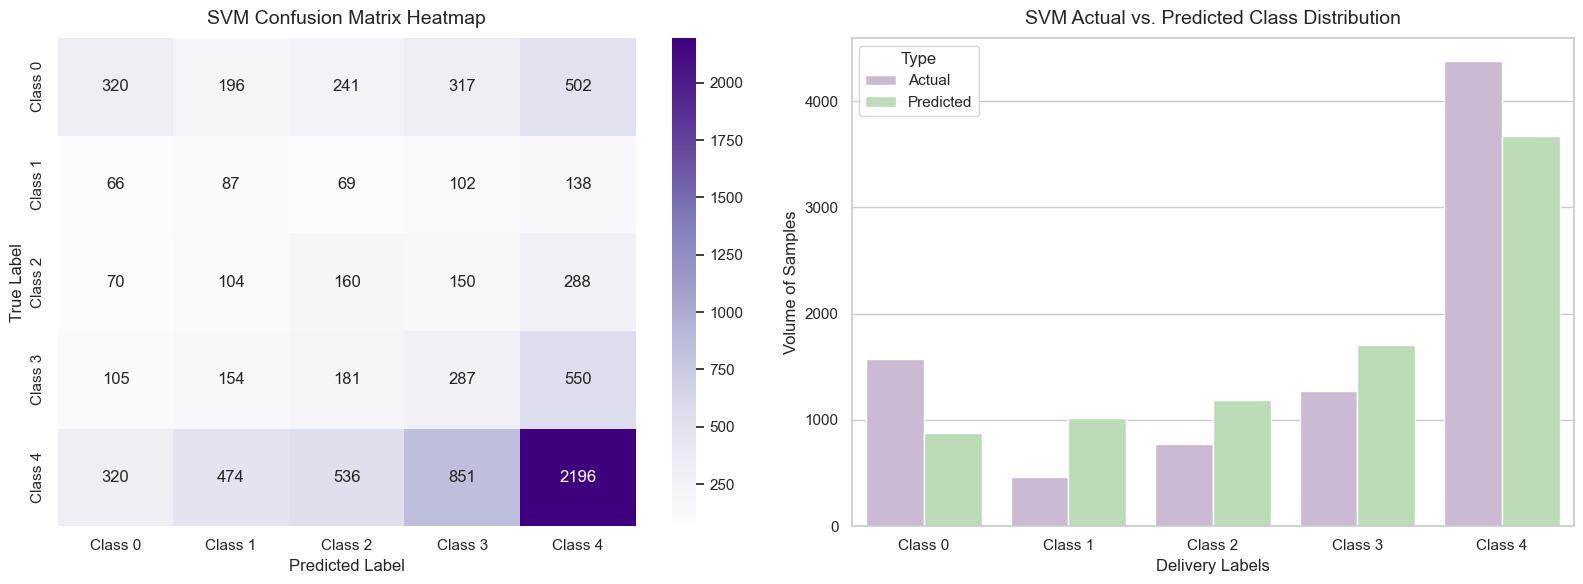

In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predicted_classes)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Purples',  # Changed to Purples to distinguish from XGBoost
    ax=axes[0],
    xticklabels=[f'Class {i}' for i in range(5)],
    yticklabels=[f'Class {i}' for i in range(5)]
)
axes[0].set_title('SVM Confusion Matrix Heatmap', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Plot B: Actual vs Predicted Class Distribution Comparison
unique, counts_actual = np.unique(y_test, return_counts=True)
unique_pred, counts_pred = np.unique(predicted_classes, return_counts=True)

dict_actual = dict(zip(unique, counts_actual))
dict_pred = dict(zip(unique_pred, counts_pred))
data_dist = {
    'Class': [f'Class {i}' for i in range(5)] * 2,
    'Count': [dict_actual.get(i, 0) for i in range(5)] + [dict_pred.get(i, 0) for i in range(5)],
    'Type': ['Actual'] * 5 + ['Predicted'] * 5
}
df_dist = pd.DataFrame(data_dist)

sns.barplot(x='Class', y='Count', hue='Type', data=df_dist, palette='PRGn', ax=axes[1])
axes[1].set_title('SVM Actual vs. Predicted Class Distribution', fontsize=14, pad=10)
axes[1].set_xlabel('Delivery Labels', fontsize=12)
axes[1].set_ylabel('Volume of Samples', fontsize=12)

plt.tight_layout()
plt.show()